# SVM

In [1]:
# Imports principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("..\\datasets_paralelos\\kmeans_7clusters.csv")

In [3]:
# 2. Separar X e y
X = df.drop(columns=['cluster'])
Y = df['cluster']

In [4]:
# 3. Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

In [5]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))  # multiclasse suportado automaticamente
])

In [6]:
# 5. Cross-validation
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Acurácias de cross-validation:", cv_scores)
print("Média da acurácia de cross-validation:", np.mean(cv_scores))

Acurácias de cross-validation: [0.98779417 0.98832104 0.98884791 0.98893572 0.98849666]
Média da acurácia de cross-validation: 0.9884791008078679


In [7]:
# 6. Treinar o pipeline completo no treino
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC())])

In [8]:
# 7. Avaliar no treino
y_train_pred = pipeline.predict(X_train)
print('Métricas de Classificação para o conjunto de treino:')
print(classification_report(y_train, y_train_pred))

Métricas de Classificação para o conjunto de treino:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     12762
           1       0.99      0.99      0.99     11214
           2       0.99      0.99      0.99      4045
           3       0.99      0.99      0.99      4586
           4       0.99      1.00      0.99      6736
           5       1.00      0.98      0.99       720
           6       1.00      0.99      0.99     16877

    accuracy                           0.99     56940
   macro avg       0.99      0.99      0.99     56940
weighted avg       0.99      0.99      0.99     56940



In [9]:
# 8. Avaliar no teste
y_test_pred = pipeline.predict(X_test)
print("Métricas de Classificação para o conjunto de teste:")
print(classification_report(y_test, y_test_pred))

Métricas de Classificação para o conjunto de teste:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5470
           1       0.99      0.99      0.99      4806
           2       0.98      0.98      0.98      1733
           3       0.99      0.99      0.99      1966
           4       0.98      0.99      0.99      2887
           5       1.00      0.96      0.98       308
           6       0.99      0.99      0.99      7233

    accuracy                           0.99     24403
   macro avg       0.99      0.98      0.99     24403
weighted avg       0.99      0.99      0.99     24403



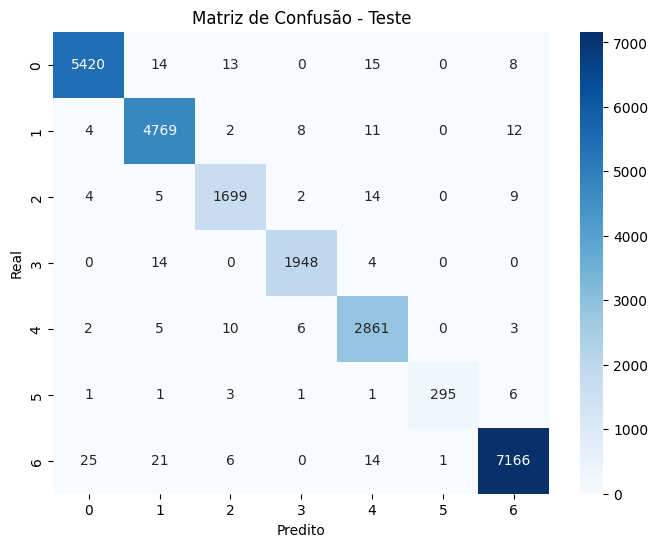

In [10]:
# 9. Matriz de confusão do teste
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(Y.unique()), yticklabels=sorted(Y.unique()))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Teste')
plt.show()

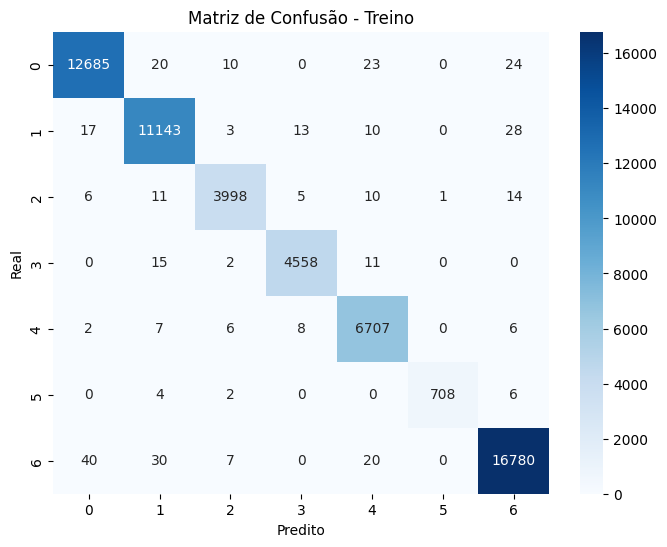

In [11]:

# Matriz de Confusão para o conjunto de treino
conf_matrix = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(Y.unique()), yticklabels=sorted(Y.unique()))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Treino')
plt.show()



c:\Users\Luan D' Miranda\Desktop\PISI3\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Luan D' Miranda\Desktop\PISI3\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Luan D' Miranda\Desktop\PISI3\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
  1%|          | 1/100 [00:18<29:43, 18.01s/it]c:\Users\Luan D' Miranda\Desktop\PISI3\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Luan D' Miranda\Desktop\PISI3\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
  2%|▏         | 2/100 [00:35<29:08, 17.84s/it]c:\Users\Luan D' Mi

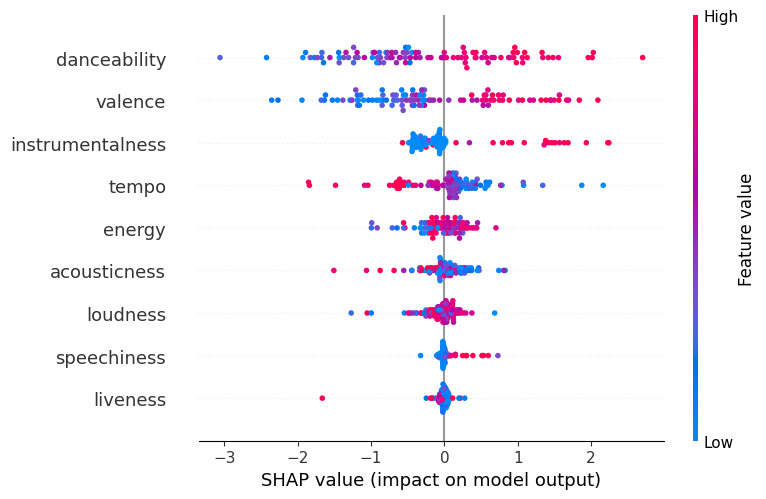

In [15]:
%pip install shap

import shap

# Usar KernelExplainer para modelos SVM
# Converter para numpy arrays para evitar problemas com feature_names_in_
background_np = background.values
test_sample_np = test_sample.values

explainer = shap.KernelExplainer(
	lambda x: pipeline.predict(x),
	background_np
)
shap_values = explainer.shap_values(test_sample_np)

# Gráfico summary plot SHAP
shap.summary_plot(shap_values, features=test_sample_np, feature_names=test_sample.columns)